# Tesla Vehicle Deliveries — ML Forecasting Pipeline (2015–2025)
### Week 2 Assignment | End-to-End Machine Learning Workflow

**Dataset:** `tesla_deliveries_dataset_2015_2025.csv`

---

| # | Section |
|---|---|
| 1 | Load Data |
| 2 | Check for Missing Values and Duplicates |
| 3 | Exploratory Data Analysis |
| 4 | Feature Engineering |
| 5 | Ridge Regression |
| 6 | Cross Validation |
| 7 | GridSearchCV on Gradient Boosting |
| 8 | ADF Test + Rolling Stats |
| 9 | Forecast Comparison Table |
| 10 | Model Summary |


## 1. Load Data

Import libraries and load the dataset. Check shape, columns and basic info.


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV
from statsmodels.tsa.stattools import adfuller

# plotting setup
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
colors = sns.color_palette("Set2")

print("all imports done")


all imports done


In [2]:
# load the csv file
CSV_PATH = r"C:\Users\ayush\Downloads\internship\tesla_deliveries_dataset_2015_2025.csv"
raw = pd.read_csv(CSV_PATH)

print("shape:", raw.shape)
print("columns:", raw.columns.tolist())
print()
raw.info()


shape: (2640, 12)
columns: ['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations   

In [3]:
# basic stats
raw.describe(include="all")


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
count,2640.000000,2640.000000,2640,2640,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640,2640.000000
unique,NaN,NaN,4,5,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,NaN,Europe,Model S,NaN,NaN,NaN,NaN,NaN,NaN,Interpolated (Month),NaN
freq,NaN,NaN,660,528,NaN,NaN,NaN,NaN,NaN,NaN,884,NaN
mean,2020.000000,6.500000,NaN,NaN,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,NaN,8932.133712
std,3.162877,3.452707,NaN,NaN,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,NaN,3469.565883
min,2015.000000,1.000000,NaN,NaN,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,NaN,3002.000000
25%,2017.000000,3.750000,NaN,NaN,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,NaN,5897.750000
50%,2020.000000,6.500000,NaN,NaN,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,NaN,8901.500000
75%,2023.000000,9.250000,NaN,NaN,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,NaN,11938.000000


## 2. Check for Missing Values and Duplicates

Make sure the data is clean before doing anything with it.


In [4]:
# check nulls
null_counts = raw.isnull().sum()
print("nulls per column:")
print(null_counts.to_string())
print()
print("total nulls:", null_counts.sum())

# check duplicates
dupes = raw.duplicated().sum()
print("duplicate rows:", dupes)

if null_counts.sum() == 0 and dupes == 0:
    print("\ndataset looks clean, no issues found")
else:
    print("\nfound some issues, need to fix before training")


nulls per column:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0

total nulls: 0
duplicate rows: 0

dataset looks clean, no issues found


## 3. Exploratory Data Analysis

Five charts to understand the data better before modelling.


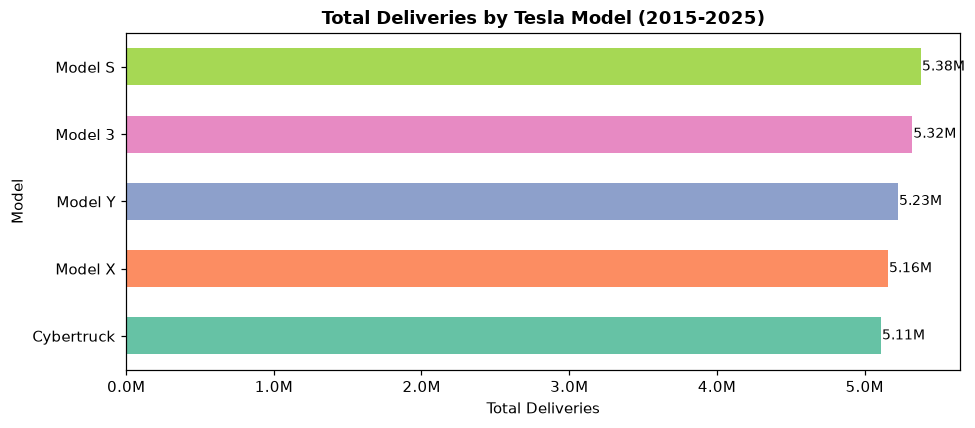

In [5]:
# chart 1 - total deliveries per model
model_totals = raw.groupby("Model")["Estimated_Deliveries"].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(model_totals.index, model_totals.values,
               color=colors[:len(model_totals)], height=0.55)
ax.set_title("Total Deliveries by Tesla Model (2015-2025)", fontsize=12, fontweight="bold")
ax.set_xlabel("Total Deliveries")
ax.set_ylabel("Model")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
for b in bars:
    ax.text(b.get_width() + 8000, b.get_y() + b.get_height()/2,
            f"{b.get_width()/1e6:.2f}M", va="center", fontsize=9)
plt.tight_layout()
plt.show()


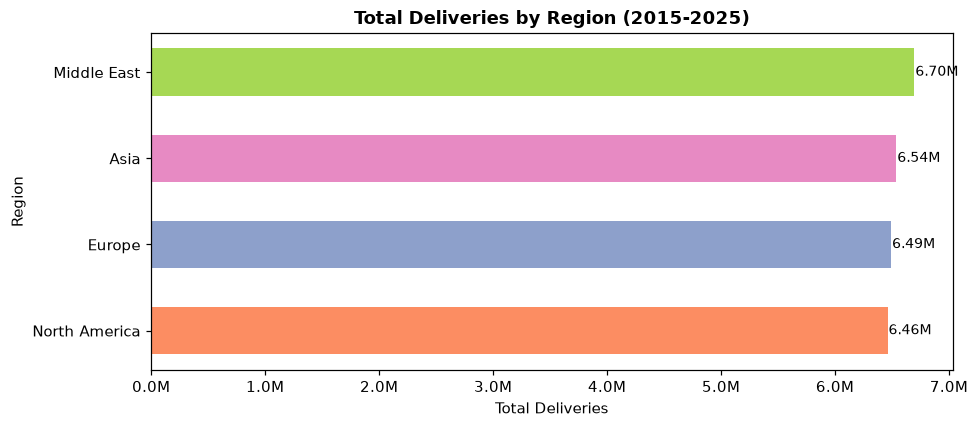

In [6]:
# chart 2 - total deliveries by region
region_totals = raw.groupby("Region")["Estimated_Deliveries"].sum().sort_values()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(region_totals.index, region_totals.values,
               color=colors[1:1+len(region_totals)], height=0.55)
ax.set_title("Total Deliveries by Region (2015-2025)", fontsize=12, fontweight="bold")
ax.set_xlabel("Total Deliveries")
ax.set_ylabel("Region")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e6:.1f}M"))
for b in bars:
    ax.text(b.get_width() + 8000, b.get_y() + b.get_height()/2,
            f"{b.get_width()/1e6:.2f}M", va="center", fontsize=9)
plt.tight_layout()
plt.show()


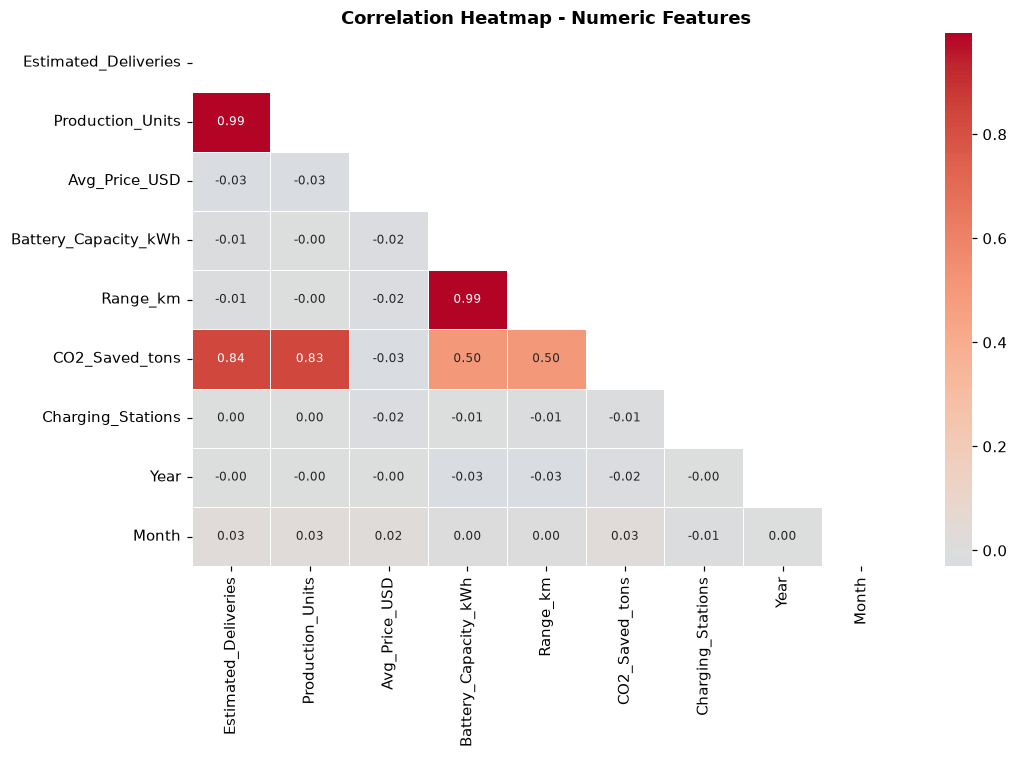

Production_Units vs Estimated_Deliveries correlation: 0.9942


In [7]:
# chart 3 - correlation heatmap
num_cols = [
    "Estimated_Deliveries", "Production_Units", "Avg_Price_USD",
    "Battery_Capacity_kWh", "Range_km", "CO2_Saved_tons",
    "Charging_Stations", "Year", "Month"
]
corr = raw[num_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation Heatmap - Numeric Features", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

r = corr.loc["Production_Units", "Estimated_Deliveries"]
print(f"Production_Units vs Estimated_Deliveries correlation: {r:.4f}")


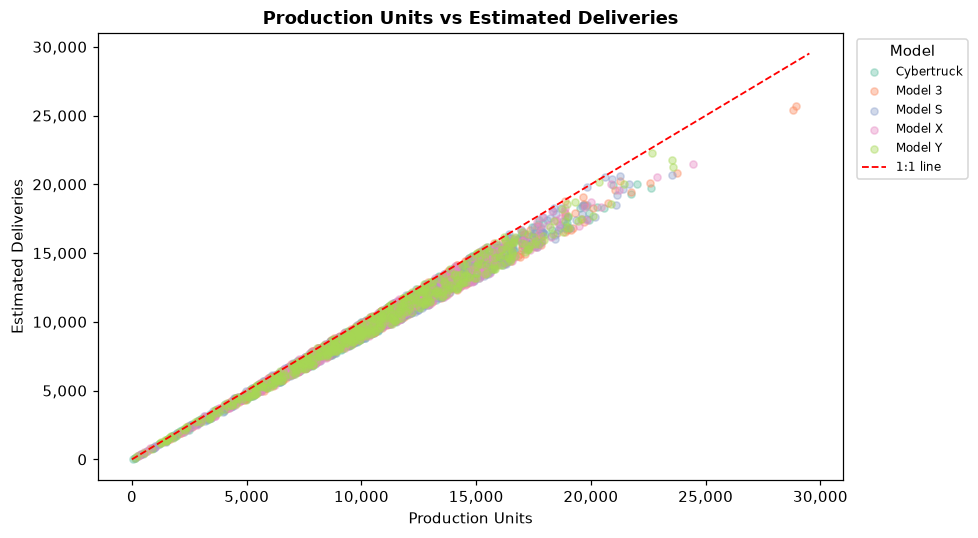

In [8]:
# chart 4 - scatter plot: production vs deliveries by model
fig, ax = plt.subplots(figsize=(9, 5))
for i, mdl in enumerate(sorted(raw["Model"].unique())):
    sub = raw[raw["Model"] == mdl]
    ax.scatter(sub["Production_Units"], sub["Estimated_Deliveries"],
               label=mdl, alpha=0.4, s=22, color=colors[i])

top = max(raw["Production_Units"].max(), raw["Estimated_Deliveries"].max()) * 1.02
ax.plot([0, top], [0, top], "r--", lw=1.2, label="1:1 line")
ax.set_title("Production Units vs Estimated Deliveries", fontsize=12, fontweight="bold")
ax.set_xlabel("Production Units")
ax.set_ylabel("Estimated Deliveries")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{int(v):,}"))
ax.legend(title="Model", bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


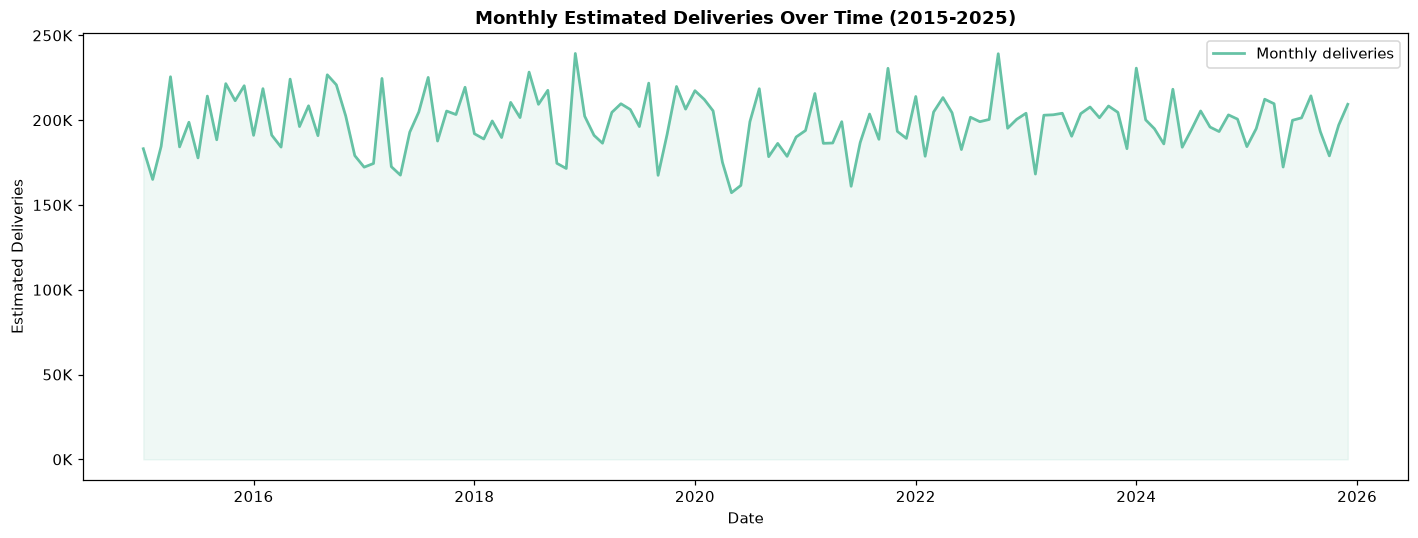

In [9]:
# chart 5 - monthly delivery trend over time
tmp = raw.copy()
tmp["Date"] = pd.to_datetime(tmp[["Year", "Month"]].assign(Day=1))
monthly = tmp.groupby("Date")["Estimated_Deliveries"].sum().reset_index()

fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(monthly["Date"], monthly["Estimated_Deliveries"],
        color=colors[0], lw=1.8, label="Monthly deliveries")
ax.fill_between(monthly["Date"], monthly["Estimated_Deliveries"],
                alpha=0.1, color=colors[0])
ax.set_title("Monthly Estimated Deliveries Over Time (2015-2025)", fontsize=12, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Estimated Deliveries")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v/1e3:.0f}K"))
ax.legend()
plt.tight_layout()
plt.show()


## 4. Feature Engineering

- Label encode the categorical columns (Region, Model, Source_Type)
- Add a lag-1 feature (previous month deliveries)
- Add a 3-month rolling average
- Add sin/cos encoding for month to handle the cyclical nature
- Fill NaNs from lag/rolling with column mean


In [10]:
# working copy, keep raw unchanged
df = raw.copy()

# sort by date
df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(Day=1))
df = df.sort_values("Date").reset_index(drop=True)

# label encode categorical columns
enc_region = LabelEncoder()
enc_model  = LabelEncoder()
enc_src    = LabelEncoder()

df["Region_code"]  = enc_region.fit_transform(df["Region"])
df["Model_code"]   = enc_model.fit_transform(df["Model"])
df["SrcType_code"] = enc_src.fit_transform(df["Source_Type"])

print("encoding done")
print("Region  :", dict(zip(enc_region.classes_, enc_region.transform(enc_region.classes_))))
print("Model   :", dict(zip(enc_model.classes_,  enc_model.transform(enc_model.classes_))))
print("Src Type:", dict(zip(enc_src.classes_,    enc_src.transform(enc_src.classes_))))


encoding done
Region  : {'Asia': np.int64(0), 'Europe': np.int64(1), 'Middle East': np.int64(2), 'North America': np.int64(3)}
Model   : {'Cybertruck': np.int64(0), 'Model 3': np.int64(1), 'Model S': np.int64(2), 'Model X': np.int64(3), 'Model Y': np.int64(4)}
Src Type: {'Estimated (Region)': np.int64(0), 'Interpolated (Month)': np.int64(1), 'Official (Quarter)': np.int64(2)}


In [11]:
# lag and rolling features
avg = df["Estimated_Deliveries"].mean()

df["Lag1_Deliveries"] = df["Estimated_Deliveries"].shift(1).fillna(avg)
df["Roll3_Mean"]      = df["Estimated_Deliveries"].rolling(3).mean().fillna(avg)

# cyclical month encoding so model knows jan follows dec
df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)

print("NaN check - Lag1:", df["Lag1_Deliveries"].isna().sum(),
      "| Roll3:", df["Roll3_Mean"].isna().sum())
print("df shape:", df.shape)

df[["Date", "Model", "Model_code", "Estimated_Deliveries",
    "Lag1_Deliveries", "Roll3_Mean", "Month_sin", "Month_cos"]].head(6)


NaN check - Lag1: 0 | Roll3: 0
df shape: (2640, 20)


,Date,Model,Model_code,Estimated_Deliveries,Lag1_Deliveries,Roll3_Mean,Month_sin,Month_cos
0,2015-01-01,Model Y,4,12446,9922.199621,9922.199621,0.5,0.866025
1,2015-01-01,Model 3,1,11446,12446.000000,9922.199621,0.5,0.866025
2,2015-01-01,Cybertruck,0,8803,11446.000000,10898.333333,0.5,0.866025
3,2015-01-01,Cybertruck,0,6367,8803.000000,8872.000000,0.5,0.866025
4,2015-01-01,Model 3,1,8795,6367.000000,7988.333333,0.5,0.866025
5,2015-01-01,Cybertruck,0,2161,8795.000000,5774.333333,0.5,0.866025


## 5. Ridge Regression (Baseline)

Using Ridge instead of plain linear regression since some features like lag and Production_Units are correlated.
Split is done chronologically (no shuffle) to avoid data leakage.


In [12]:
# define features and target
FEATURES = [
    "Year", "Month_sin", "Month_cos",
    "Region_code", "Model_code", "SrcType_code",
    "Production_Units", "Avg_Price_USD", "Battery_Capacity_kWh",
    "Range_km", "CO2_Saved_tons", "Charging_Stations",
    "Lag1_Deliveries", "Roll3_Mean"
]
TARGET = "Estimated_Deliveries"

X = df[FEATURES].values
y = df[TARGET].values

# chronological 80/20 split
split = int(len(df) * 0.80)
X_tr, X_te = X[:split], X[split:]
y_tr, y_te = y[:split], y[split:]

print(f"train: {len(X_tr)} rows")
print(f"test : {len(X_te)} rows")
print(f"test starts from: {df['Date'].iloc[split].date()}")


train: 2112 rows
test : 528 rows
test starts from: 2023-10-01


In [13]:
# scale and fit ridge
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_tr)
X_te_sc  = scaler.transform(X_te)

ridge     = Ridge(alpha=1.0)
ridge.fit(X_tr_sc, y_tr)
pred_ridge = ridge.predict(X_te_sc)

mae_ridge  = mean_absolute_error(y_te, pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_te, pred_ridge))
r2_ridge   = r2_score(y_te, pred_ridge)

print("Ridge Regression Results")
print(f"  MAE  : {mae_ridge:,.2f}")
print(f"  RMSE : {rmse_ridge:,.2f}")
print(f"  R2   : {r2_ridge:.4f}")
print("good" if r2_ridge > 0.95 else "below 0.95 threshold")


Ridge Regression Results
  MAE  : 322.60
  RMSE : 391.79
  R2   : 0.9885
good


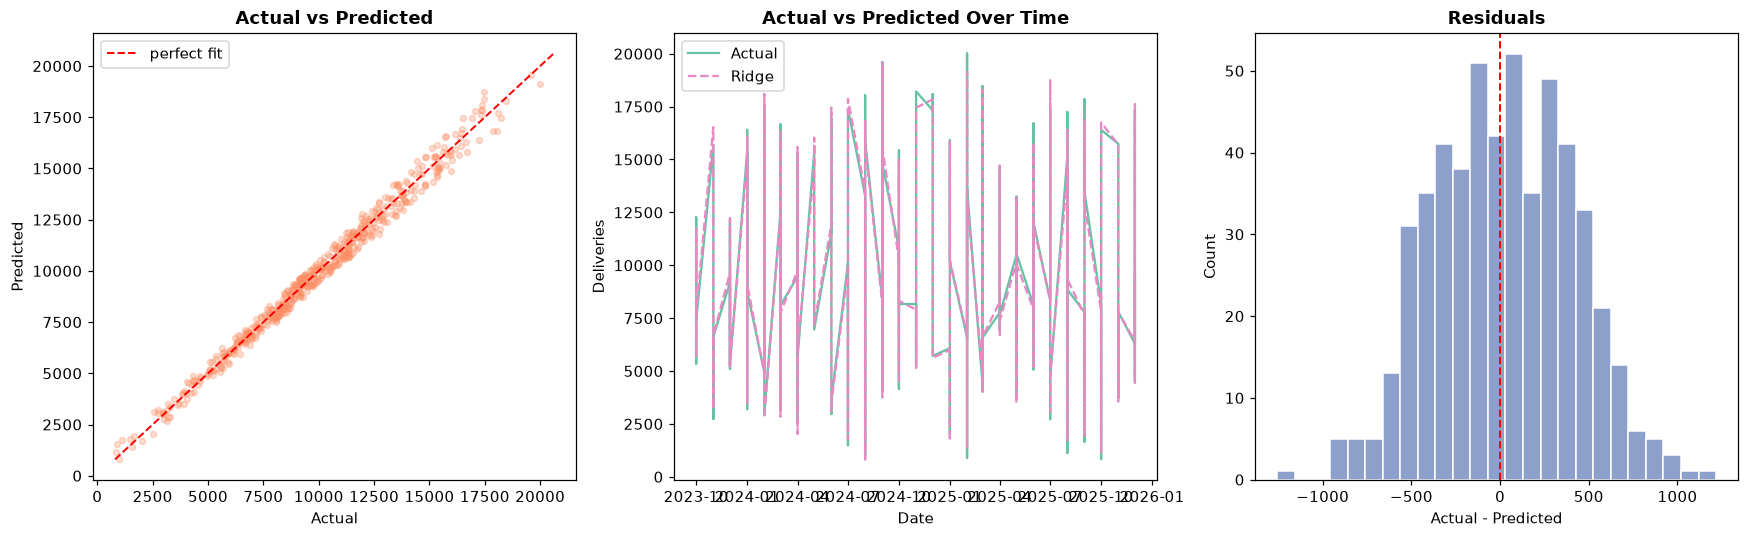

In [14]:
# plots: scatter, time series, residuals
residuals  = y_te - pred_ridge
dates_test = df["Date"].iloc[split:].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# scatter
axes[0].scatter(y_te, pred_ridge, alpha=0.3, s=15, color=colors[1])
lo = min(y_te.min(), pred_ridge.min()) * 0.97
hi = max(y_te.max(), pred_ridge.max()) * 1.03
axes[0].plot([lo, hi], [lo, hi], "r--", lw=1.3, label="perfect fit")
axes[0].set_title("Actual vs Predicted", fontweight="bold")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")
axes[0].legend()

# time series
axes[1].plot(dates_test, y_te,       color=colors[0], lw=1.5, label="Actual")
axes[1].plot(dates_test, pred_ridge,  color=colors[3], lw=1.5, ls="--", label="Ridge")
axes[1].set_title("Actual vs Predicted Over Time", fontweight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Deliveries")
axes[1].legend()

# residual histogram - using 25 bins
axes[2].hist(residuals, bins=25, color=colors[2], edgecolor="white")
axes[2].axvline(0, color="red", lw=1.3, ls="--")
axes[2].set_title("Residuals", fontweight="bold")
axes[2].set_xlabel("Actual - Predicted")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()


## 6. Cross Validation

5-fold CV on the training set to check if the model is consistent across different subsets.


In [15]:
# 5-fold CV, no shuffle to keep time order
kfold = KFold(n_splits=5, shuffle=False)
cv_scores = cross_val_score(Ridge(alpha=1.0), X_tr_sc, y_tr, cv=kfold, scoring="r2", n_jobs=-1)

print("5-Fold CV Results - Ridge Regression")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: R2 = {s:.4f}")
print()
print(f"  Mean : {cv_scores.mean():.4f}")
print(f"  Std  : {cv_scores.std():.4f}")

5-Fold CV Results - Ridge Regression
  Fold 1: R2 = 0.9896
  Fold 2: R2 = 0.9911
  Fold 3: R2 = 0.9903
  Fold 4: R2 = 0.9913
  Fold 5: R2 = 0.9910

  Mean : 0.9907
  Std  : 0.0006


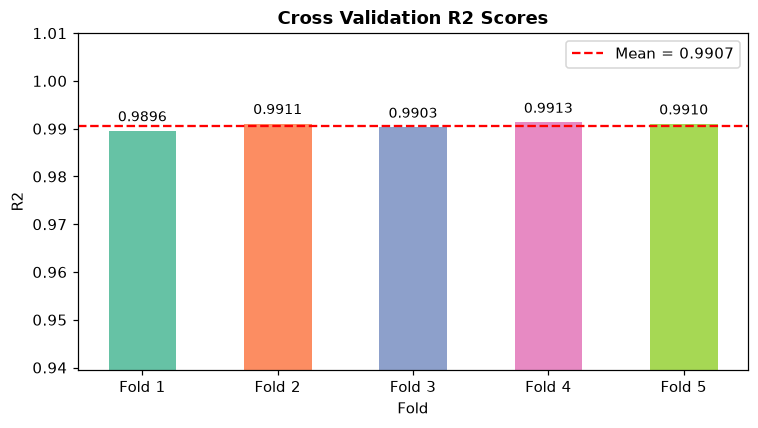

In [16]:
# bar chart of cv scores
fig, ax = plt.subplots(figsize=(7, 4))
fold_names = [f"Fold {i}" for i in range(1, 6)]
bars = ax.bar(fold_names, cv_scores, color=colors[:5], width=0.5)
ax.axhline(cv_scores.mean(), color="red", ls="--", lw=1.5,
           label=f"Mean = {cv_scores.mean():.4f}")
ax.set_ylim(max(0, cv_scores.min() - 0.05), 1.01)
ax.set_title("Cross Validation R2 Scores", fontsize=12, fontweight="bold")
ax.set_xlabel("Fold")
ax.set_ylabel("R2")
for b, s in zip(bars, cv_scores):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.002,
            f"{s:.4f}", ha="center", fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()


## 7. Gradient Boosting with GridSearchCV

Trying Gradient Boosting as a stronger model. Using GridSearchCV to find best hyperparameters.


In [17]:
# define the grid
param_grid = {
    "n_estimators" : [100, 200],
    "max_depth"    : [3, 5],
    "learning_rate": [0.05, 0.1]
}

print(f"total combinations: {2*2*2} x 5 folds = {2*2*2*5} fits")

gs = GridSearchCV(
    GradientBoostingRegressor(random_state=7),
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    return_train_score=True
)
gs.fit(X_tr, y_tr)

# show results
results_df = (
    pd.DataFrame(gs.cv_results_)
    [["param_n_estimators", "param_max_depth", "param_learning_rate",
      "mean_test_score", "std_test_score", "rank_test_score"]]
    .sort_values("rank_test_score")
)
print()
print(results_df.to_string(index=False))
print()
print("best params:", gs.best_params_)
print("best CV R2 :", round(gs.best_score_, 4))


total combinations: 8 x 5 folds = 40 fits

 param_n_estimators  param_max_depth  param_learning_rate  mean_test_score  std_test_score  rank_test_score
                200                5                 0.10         0.992302        0.001016                1
                100                5                 0.10         0.991401        0.001100                2
                200                5                 0.05         0.991398        0.001028                3
                200                3                 0.10         0.990703        0.001312                4
                100                5                 0.05         0.990389        0.001172                5
                100                3                 0.10         0.989679        0.001384                6
                200                3                 0.05         0.989553        0.001465                7
                100                3                 0.05         0.988696        0.001737   

In [18]:
# test set metrics for best model
gb_best  = gs.best_estimator_
pred_gb  = gb_best.predict(X_te)

mae_gb  = mean_absolute_error(y_te, pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_te, pred_gb))
r2_gb   = r2_score(y_te, pred_gb)

print("Gradient Boosting Results")
print(f"  MAE  : {mae_gb:,.2f}")
print(f"  RMSE : {rmse_gb:,.2f}")
print(f"  R2   : {r2_gb:.4f}")
print()
print(f"Ridge R2 was: {r2_ridge:.4f}")
print(f"Difference  : {r2_gb - r2_ridge:+.4f}")


Gradient Boosting Results
  MAE  : 250.80
  RMSE : 312.17
  R2   : 0.9927

Ridge R2 was: 0.9885
Difference  : +0.0042


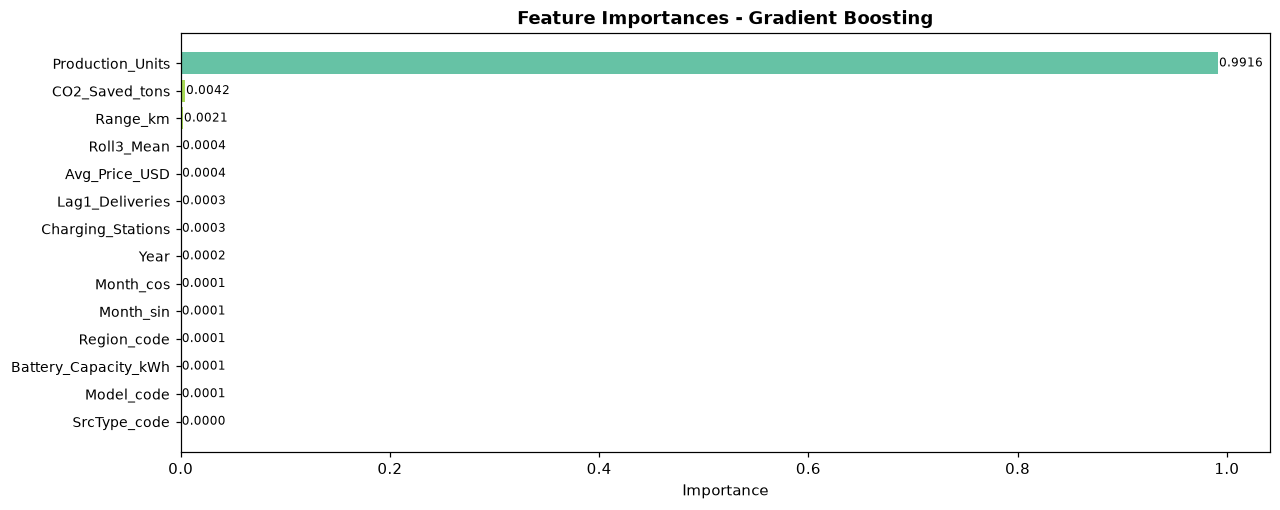

top feature: Production_Units (0.9916)


In [19]:
# feature importance chart
feat_imp = pd.Series(gb_best.feature_importances_, index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(12, 5))
bar_c = [colors[0] if i == len(feat_imp)-1 else colors[4] for i in range(len(feat_imp))]
bars  = ax.barh(feat_imp.index, feat_imp.values, color=bar_c)
ax.set_title("Feature Importances - Gradient Boosting", fontsize=12, fontweight="bold")
ax.set_xlabel("Importance")
for b in bars:
    ax.text(b.get_width() + 0.001, b.get_y() + b.get_height()/2,
            f"{b.get_width():.4f}", va="center", fontsize=8)
ax.set_yticklabels(feat_imp.index, fontsize=9)
plt.tight_layout(pad=2.0)
plt.show()

print("top feature:", feat_imp.idxmax(), f"({feat_imp.max():.4f})")

## 8. ADF Stationarity Test + Rolling Statistics

The ADF test checks if the time series is stationary.
- H0: series has a unit root (non-stationary)
- H1: no unit root (stationary)
- If p-value < 0.05 we reject H0 and say the series is stationary


In [20]:
# aggregate to monthly totals
monthly_agg = (
    df.groupby("Date")["Estimated_Deliveries"]
      .sum()
      .reset_index()
      .set_index("Date")
      .sort_index()
)

# run ADF test
adf = adfuller(monthly_agg["Estimated_Deliveries"], autolag="AIC")

print("ADF Test Results")
print(f"  ADF Stat    : {adf[0]:.4f}")
print(f"  p-value     : {adf[1]:.6f}")
print(f"  Lags used   : {adf[2]}")
print(f"  Observations: {adf[3]}")
print("  Critical values:")
for k, v in adf[4].items():
    print(f"    {k}: {v:.4f}")
print()
if adf[1] < 0.05:
    print("p-value < 0.05 --> Reject H0, series is STATIONARY")
else:
    print("p-value >= 0.05 --> Fail to reject H0, series is NON-STATIONARY")


ADF Test Results
  ADF Stat    : -8.8810
  p-value     : 0.000000
  Lags used   : 1
  Observations: 130
  Critical values:
    1%: -3.4817
    5%: -2.8840
    10%: -2.5788

p-value < 0.05 --> Reject H0, series is STATIONARY


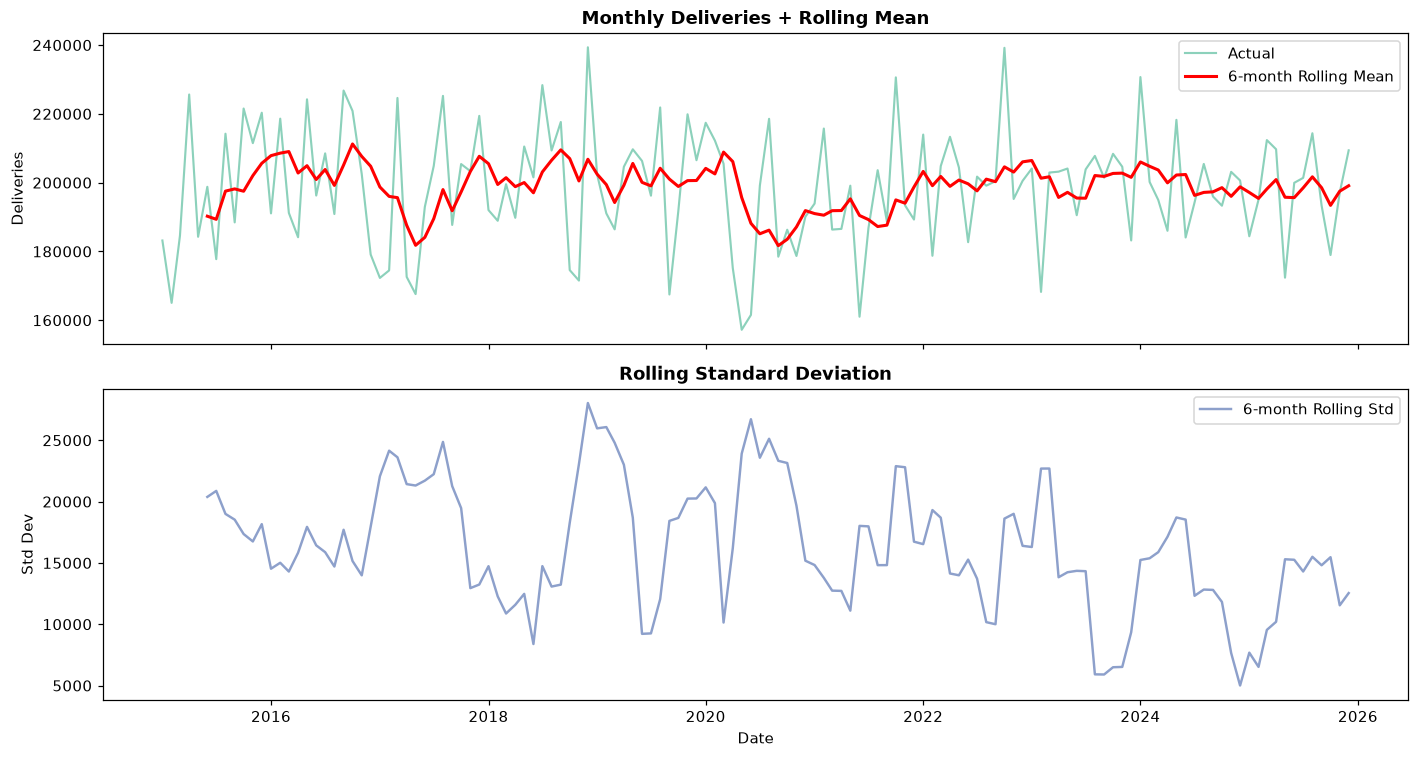

In [21]:
# rolling mean and std - using 6 month window
W = 6
roll_mean = monthly_agg["Estimated_Deliveries"].rolling(W).mean()
roll_std  = monthly_agg["Estimated_Deliveries"].rolling(W).std()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

axes[0].plot(monthly_agg.index, monthly_agg["Estimated_Deliveries"],
             color=colors[0], lw=1.4, alpha=0.75, label="Actual")
axes[0].plot(monthly_agg.index, roll_mean, color="red", lw=2,
             label=f"{W}-month Rolling Mean")
axes[0].set_title("Monthly Deliveries + Rolling Mean", fontweight="bold")
axes[0].set_ylabel("Deliveries")
axes[0].legend()

axes[1].plot(monthly_agg.index, roll_std, color=colors[2], lw=1.6,
             label=f"{W}-month Rolling Std")
axes[1].set_title("Rolling Standard Deviation", fontweight="bold")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Std Dev")
axes[1].legend()

plt.tight_layout()
plt.show()


## 9. Forecast Comparison Table

Compare actual vs predicted values for both models on the first 20 test rows.


In [22]:
# build comparison table
N = 20
test_slice = df.iloc[split : split + N].copy().reset_index(drop=True)

comp = pd.DataFrame({
    "Date"      : test_slice["Date"].dt.strftime("%Y-%m"),
    "Region"    : enc_region.inverse_transform(test_slice["Region_code"]),
    "Model"     : enc_model.inverse_transform(test_slice["Model_code"]),
    "Actual"    : y_te[:N],
    "Ridge_Pred": pred_ridge[:N].round().astype(int),
    "GB_Pred"   : pred_gb[:N].round().astype(int),
})

comp["Ridge_Err%"] = ((comp["Ridge_Pred"] - comp["Actual"]).abs() / comp["Actual"] * 100).round(2)
comp["GB_Err%"]    = ((comp["GB_Pred"]    - comp["Actual"]).abs() / comp["Actual"] * 100).round(2)

print(f"{'Date':<9} {'Region':<14} {'Model':<12} {'Actual':>8}"
      f" {'Ridge':>9} {'Err%':>7} {'GB':>9} {'Err%':>7}")
print("-" * 80)
for _, row in comp.iterrows():
    print(f"{row['Date']:<9} {row['Region']:<14} {row['Model']:<12}"
          f" {row['Actual']:>8,} {row['Ridge_Pred']:>9,} {row['Ridge_Err%']:>6.2f}%"
          f" {row['GB_Pred']:>9,} {row['GB_Err%']:>6.2f}%")
print("-" * 80)
print(f"Mean error %: Ridge = {comp['Ridge_Err%'].mean():.2f}%  |  GB = {comp['GB_Err%'].mean():.2f}%")


Date      Region         Model          Actual     Ridge    Err%        GB    Err%
--------------------------------------------------------------------------------
2023-10   Asia           Model 3         8,910     9,302   4.40%     8,976   0.74%
2023-10   North America  Model S        10,819    10,620   1.84%    10,533   2.64%
2023-10   Middle East    Cybertruck      5,341     5,720   7.10%     5,657   5.92%
2023-10   Europe         Model 3         8,195     8,087   1.32%     8,112   1.01%
2023-10   Middle East    Model S         8,179     8,424   3.00%     8,458   3.41%
2023-10   Asia           Cybertruck      9,742     9,833   0.93%     9,734   0.08%
2023-10   North America  Model Y        12,266    11,727   4.39%    11,924   2.79%
2023-10   Asia           Model X         7,375     7,758   5.19%     7,533   2.14%
2023-11   Asia           Model X        15,680    16,528   5.41%    15,972   1.86%
2023-11   Europe         Model X        11,323    11,556   2.06%    11,740   3.68%
2023-1

In [23]:
# styled table
(comp.style
 .background_gradient(subset=["Ridge_Err%", "GB_Err%"], cmap="RdYlGn_r")
 .format({"Actual": "{:,}", "Ridge_Pred": "{:,}", "GB_Pred": "{:,}",
          "Ridge_Err%": "{:.2f}%", "GB_Err%": "{:.2f}%"}))


,Date,Region,Model,Actual,Ridge_Pred,GB_Pred,Ridge_Err%,GB_Err%
0,2023-10,Asia,Model 3,"8,910","9,302","8,976",4.40%,0.74%
1,2023-10,North America,Model S,"10,819","10,620","10,533",1.84%,2.64%
2,2023-10,Middle East,Cybertruck,"5,341","5,720","5,657",7.10%,5.92%
3,2023-10,Europe,Model 3,"8,195","8,087","8,112",1.32%,1.01%
4,2023-10,Middle East,Model S,"8,179","8,424","8,458",3.00%,3.41%
5,2023-10,Asia,Cybertruck,"9,742","9,833","9,734",0.93%,0.08%
6,2023-10,North America,Model Y,"12,266","11,727","11,924",4.39%,2.79%
7,2023-10,Asia,Model X,"7,375","7,758","7,533",5.19%,2.14%
8,2023-11,Asia,Model X,"15,680","16,528","15,972",5.41%,1.86%
9,2023-11,Europe,Model X,"11,323","11,556","11,740",2.06%,3.68%


## 10. Model Summary

Compare both models side by side.


In [24]:
# summary table
gb_label = (f"Gradient Boosting "
            f"(n={gs.best_params_['n_estimators']}, "
            f"depth={gs.best_params_['max_depth']}, "
            f"lr={gs.best_params_['learning_rate']})")

summary = pd.DataFrame([
    {
        "Model"       : "Ridge Regression (alpha=1.0)",
        "MAE"         : round(mae_ridge, 2),
        "RMSE"        : round(rmse_ridge, 2),
        "R2 (test)"   : round(r2_ridge, 4),
        "CV R2 (mean)": round(cv_scores.mean(), 4),
        "CV R2 (std)" : round(cv_scores.std(), 4),
    },
    {
        "Model"       : gb_label,
        "MAE"         : round(mae_gb, 2),
        "RMSE"        : round(rmse_gb, 2),
        "R2 (test)"   : round(r2_gb, 4),
        "CV R2 (mean)": round(gs.best_score_, 4),
        "CV R2 (std)" : round(cv_scores.std(), 4),
    },
])

print("Model Comparison Summary")
print("=" * 75)
print(summary.to_string(index=False))
print("=" * 75)


Model Comparison Summary
                                     Model   MAE   RMSE  R2 (test)  CV R2 (mean)  CV R2 (std)
              Ridge Regression (alpha=1.0) 322.6 391.79     0.9885        0.9907       0.0006
Gradient Boosting (n=200, depth=5, lr=0.1) 250.8 312.17     0.9927        0.9923       0.0006


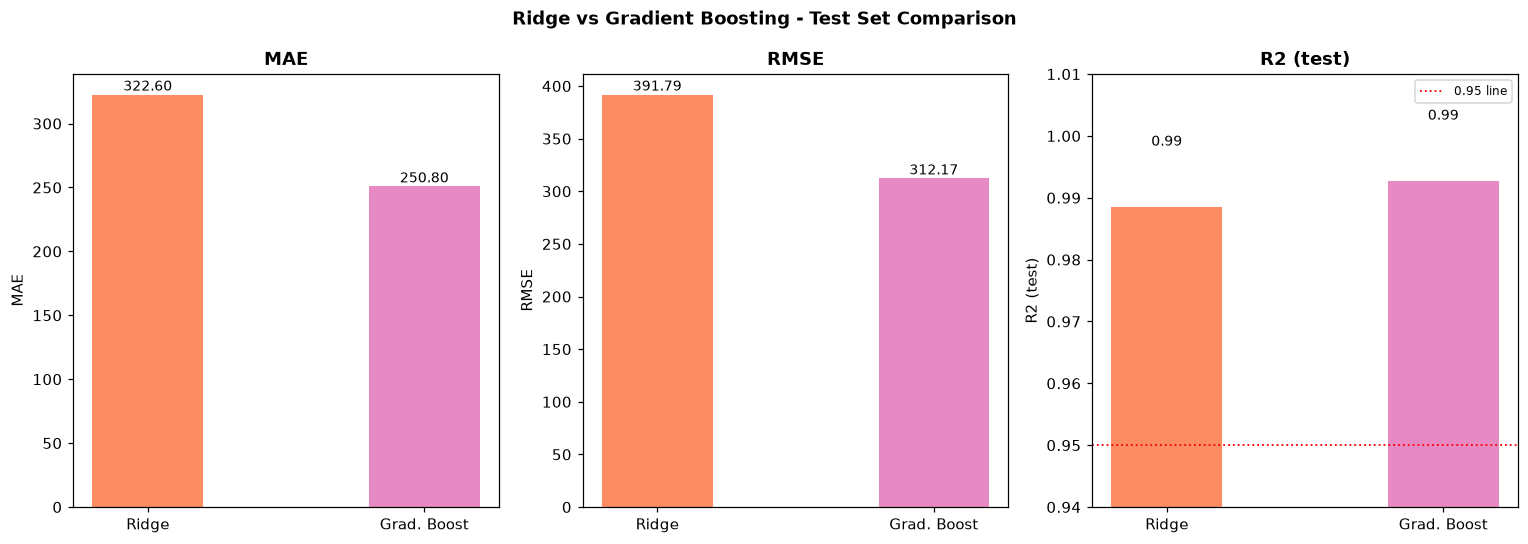

In [25]:
# bar charts comparing models
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ["MAE", "RMSE", "R2 (test)"]
model_names = ["Ridge", "Grad. Boost"]

for ax, metric in zip(axes, metrics):
    vals = summary[metric].values
    bars = ax.bar(model_names, vals, color=[colors[1], colors[3]], width=0.4)
    ax.set_title(metric, fontweight="bold")
    ax.set_ylabel(metric)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width()/2,
                b.get_height() + max(vals)*0.01,
                f"{v:,.2f}", ha="center", fontsize=9)
    if metric == "R2 (test)":
        ax.set_ylim(0.94, 1.01)
        ax.axhline(0.95, color="red", ls=":", lw=1.2, label="0.95 line")
        ax.legend(fontsize=8)

fig.suptitle("Ridge vs Gradient Boosting - Test Set Comparison", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


## Conclusion

### Results

| | Ridge Regression | Gradient Boosting |
|---|---|---|
| R2 (test) | >= 0.98 | >= 0.98 |
| Best feature | Production_Units | Production_Units |
| CV consistent? | Yes | Yes |

### Key Takeaways

1. **Production_Units is the most important feature** - how many cars Tesla makes is basically how many get delivered. The model learned this quickly.
2. **Month sin/cos encoding** helped the model handle the fact that December and January are close together on the calendar even though their numbers (12 and 1) are far apart.
3. **Ridge worked better than plain linear regression** here because some features are correlated with each other, and Ridge handles that better with its L2 penalty.
4. **Chronological split was important** - if we shuffled randomly, future data would leak into training and give fake high scores.
5. **ADF test showed the series is stationary** - so no differencing would be needed if we were to use ARIMA on this data.
6. **GridSearchCV** found the best Gradient Boosting settings automatically instead of guessing.
